# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [5]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [6]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [7]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [8]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

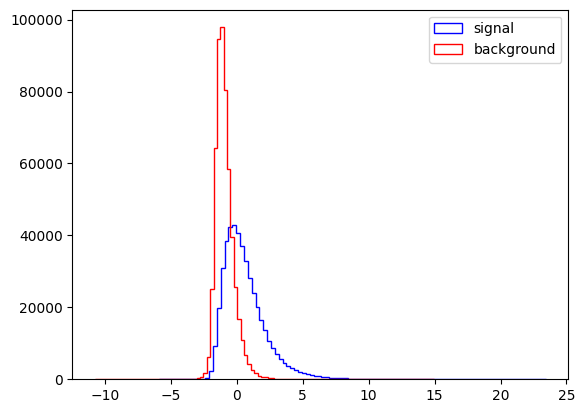

In [9]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

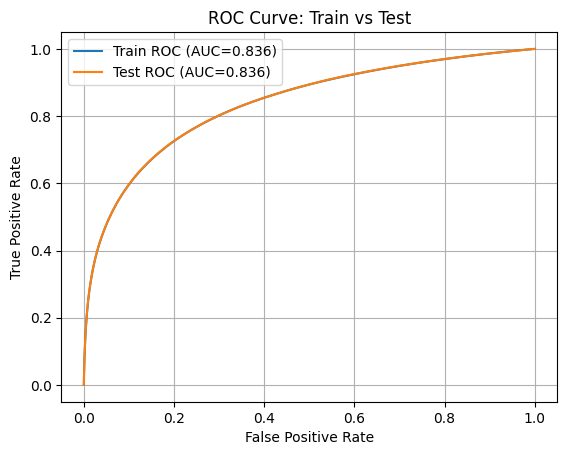

In [10]:
train_score=Fisher.decision_function(X_Train)
test_score=Fisher.decision_function(X_Test)

from sklearn.metrics import roc_curve, auc
fpr_train, tpr_train, _ = roc_curve(y_Train, train_score)
fpr_test, tpr_test, _ = roc_curve(y_Test, test_score)

auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

import matplotlib.pyplot as plt

plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.3f})")
plt.plot(fpr_test,  tpr_test,  label=f"Test ROC (AUC={auc_test:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Train vs Test")
plt.legend()
plt.grid(True)
plt.show()


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

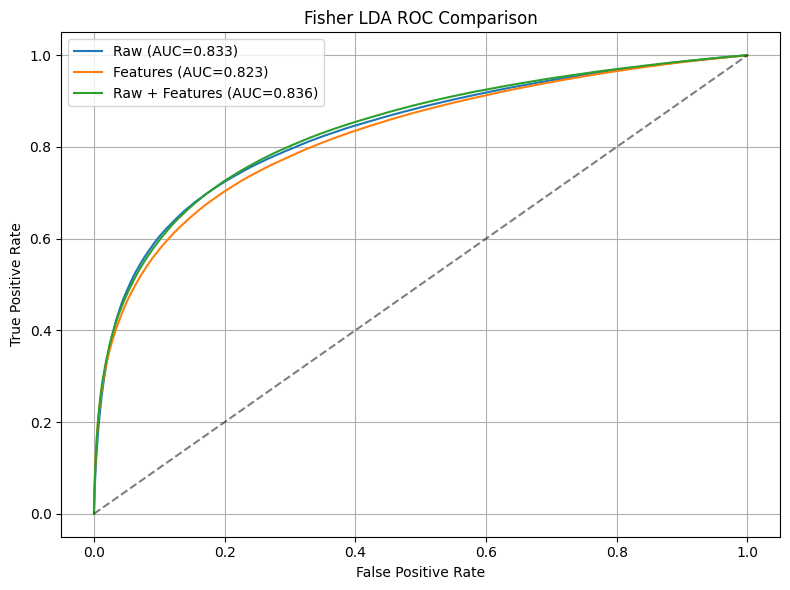

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))


# ---------------------------------------------------------
# 1. Extract raw, engineered, and combined features
# ---------------------------------------------------------

# RAW features 
X_raw_train  = Train_Sample[RawNames]    
X_raw_test   = Test_Sample[RawNames]

# ENGINEERED features 
X_feat_train = Train_Sample[FeatureNames]    
X_feat_test  = Test_Sample[FeatureNames]

# RAW + ENGINEERED
X_rawfeat_train = Train_Sample[VarNames[1:] + FeatureNames]
X_rawfeat_test  = Test_Sample[VarNames[1:] + FeatureNames]

# Labels
y_train = y_Train
y_test  = y_Test

# ---------------------------------------------------------
# 2. Train Fisher LDA models
# ---------------------------------------------------------
lda_raw      = LinearDiscriminantAnalysis().fit(X_raw_train, y_train)
lda_feat     = LinearDiscriminantAnalysis().fit(X_feat_train, y_train)
lda_rawfeat  = LinearDiscriminantAnalysis().fit(X_rawfeat_train, y_train)

# ---------------------------------------------------------
# 3. Get discriminant scores (decision_function)
# ---------------------------------------------------------
z_raw      = lda_raw.decision_function(X_raw_test)
z_feat     = lda_feat.decision_function(X_feat_test)
z_rawfeat  = lda_rawfeat.decision_function(X_rawfeat_test)

# ---------------------------------------------------------
# 4. Compute ROC curves
# ---------------------------------------------------------
fpr_raw, tpr_raw, _ = roc_curve(y_test, z_raw)
fpr_feat, tpr_feat, _ = roc_curve(y_test, z_feat)
fpr_rawfeat, tpr_rawfeat, _ = roc_curve(y_test, z_rawfeat)

auc_raw      = auc(fpr_raw, tpr_raw)
auc_feat     = auc(fpr_feat, tpr_feat)
auc_rawfeat  = auc(fpr_rawfeat, tpr_rawfeat)

# ---------------------------------------------------------
# 5. Plot all ROC curves on one figure
# ---------------------------------------------------------
plt.figure(figsize=(8,6))

plt.plot(fpr_raw, tpr_raw, label=f"Raw (AUC={auc_raw:.3f})")
plt.plot(fpr_feat, tpr_feat, label=f"Features (AUC={auc_feat:.3f})")
plt.plot(fpr_rawfeat, tpr_rawfeat, label=f"Raw + Features (AUC={auc_rawfeat:.3f})")

plt.plot([0,1], [0,1], 'k--', alpha=0.5)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher LDA ROC Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

LogisticRegression

RandomForestClassifier

KNeighborsClassifier

In [14]:
from sklearn.metrics import roc_curve, auc

def evaluate_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    scores = clf.predict_proba(X_test)[:,1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    return fpr, tpr, auc(fpr, tpr)


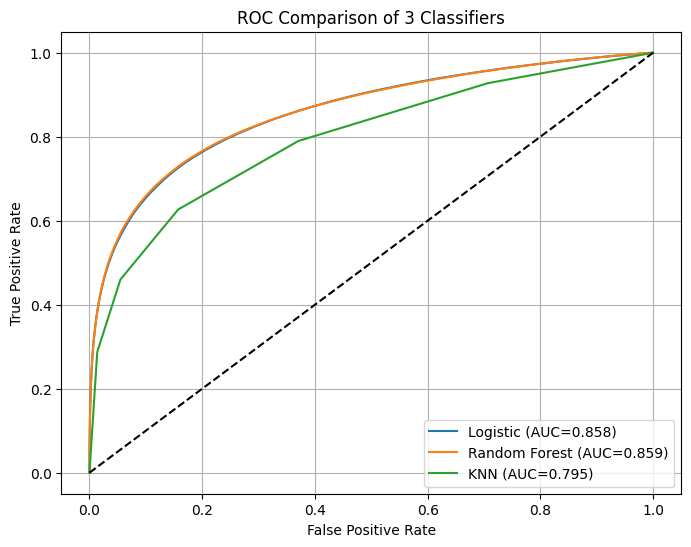

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

clfs = {
    "Logistic": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

N_small = 10000  # Use a smaller subset for faster evaluation
X_small = X_Train[:N_small]
y_small = y_Train[:N_small]

plt.figure(figsize=(8,6))

for name, clf in clfs.items():
    fpr, tpr, auc_val = evaluate_classifier(clf, X_small, y_small, X_Test, y_Test)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of 3 Classifiers")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import numpy as np

# best_clf is chosen from part (b)
best_clf = RandomForestClassifier(n_estimators=100)
best_clf.fit(X_small, y_small)

scores = best_clf.predict_proba(X_small)[:,1]

thresholds = np.linspace(0,1,200)
max_sig = 0

for t in thresholds:
    preds = scores > t
    N_S = ((preds == 1) & (y_small == 1)).sum()
    N_B = ((preds == 1) & (y_small == 0)).sum()
    if N_S + N_B > 0:
        sig = N_S / np.sqrt(N_S + N_B)
        max_sig = max(max_sig, sig)

print("Maximal significance:", max_sig)

Maximal significance: 67.67569726275453


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [21]:
from sklearn.metrics import (
    roc_curve, auc, precision_score, recall_score,
    f1_score, accuracy_score
)
import numpy as np
import pandas as pd

# Fit best classifier on the small dataset
best_clf.fit(X_small, y_small)

# Continuous scores for ROC + significance (on small dataset)
scores = (
    best_clf.predict_proba(X_small)[:,1]
    if hasattr(best_clf, "predict_proba")
    else best_clf.decision_function(X_small)
)

# Hard predictions for precision/recall/F1/accuracy (on small dataset)
y_pred = best_clf.predict(X_small)

# ROC + AUC (on small dataset)
fpr, tpr, _ = roc_curve(y_small, scores)
auc_val = auc(fpr, tpr)

# Precision, Recall, F1, Accuracy (on small dataset)
precision = precision_score(y_small, y_pred)
recall    = recall_score(y_small, y_pred)
f1        = f1_score(y_small, y_pred)
accuracy  = accuracy_score(y_small, y_pred)

# Maximal significance (on small dataset)
thresholds = np.linspace(0, 1, 300)
max_sig = 0

for t in thresholds:
    preds = scores > t
    N_S = ((preds == 1) & (y_small == 1)).sum()
    N_B = ((preds == 1) & (y_small == 0)).sum()
    if N_S + N_B > 0:
        sig = N_S / np.sqrt(N_S + N_B)
        max_sig = max(max_sig, sig)

# Results table
results = pd.DataFrame({
    "Metric": [
        "AUC", "Precision", "Recall", "F1 Score",
        "Accuracy", "Max Significance"
    ],
    "Value": [
        auc_val, precision, recall, f1,
        accuracy, max_sig
    ]
})

print(results)


             Metric      Value
0               AUC   1.000000
1         Precision   1.000000
2            Recall   1.000000
3          F1 Score   1.000000
4          Accuracy   1.000000
5  Max Significance  67.675697
